# 03 · Compartment review

This read-only notebook summarizes CellCharter spatial domains and nearest-neighbor composition, then provides a focused review of one domain and one source cell type.

Set the review choices in `configs/local.yaml`, run the notebook from top to bottom, and use the focused panels to decide which domains or cell populations warrant follow-up analysis.

In [ ]:
import importlib
import sys
from pathlib import Path

import anndata as ad
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SOURCE_ROOT = str(REPO_ROOT / "src")
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)

from spatial_workflow.config import load_config, resolve_path
from spatial_workflow import review as review_module
importlib.reload(review_module)
from spatial_workflow.review import (
    available_compartments,
    compartment_composition,
    load_autok_outputs,
    load_review_outputs,
    neighbor_fraction_matrix,
    plot_autok_stability,
    plot_compartment_composition,
    plot_compartment_overview,
    plot_neighbor_fraction_heatmap,
    plot_reciprocal_celltype_overlap,
    plot_spatial_domains,
    prepare_reciprocal_celltype_plot,
    summarize_compartments,
)

CONFIG_PATH = REPO_ROOT / "configs" / "local.yaml"
config = load_config(CONFIG_PATH)
results_root = resolve_path(CONFIG_PATH, config["paths"]["results_root"])
input_h5ad = resolve_path(CONFIG_PATH, config["nncomp"]["input_h5ad"], root=results_root)
output_dir = resolve_path(CONFIG_PATH, config["nncomp"]["output_dir"], root=results_root)
cellcharter_output_dir = resolve_path(CONFIG_PATH, config["cellcharter"]["output_dir"], root=results_root)

autok = load_autok_outputs(cellcharter_output_dir, config["cellcharter"]["output_name"])
tables = load_review_outputs(output_dir)
adata = ad.read_h5ad(input_h5ad, backed="r")

## AutoK stability and K selection

The stability curve shows how consistently CellCharter recovers each candidate number of domains. The vertical line marks the selected value of K; open points identify local stability peaks.

,AutoK
execution mode,reused_prior_run
selected K,13
stability peaks,"[4, 8, 13]"


,k,mean_stability,sd_stability,n_comparisons
0,2,0.715311,0.046028,90
1,3,0.717244,0.070847,90
2,4,0.720364,0.086313,90
3,5,0.719466,0.084287,90
4,6,0.697505,0.090135,90
5,7,0.733091,0.107498,90
6,8,0.749865,0.098039,90
7,9,0.697833,0.099405,90
8,10,0.695031,0.089792,90
9,11,0.694336,0.081080,90


<Axes: title={'center': 'CellCharter AutoK stability'}, xlabel='K', ylabel='Mean stability'>

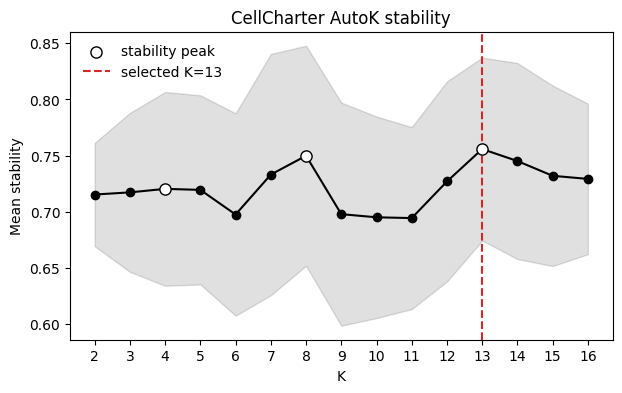

In [2]:
autok_summary = autok["summary"]
display(pd.Series({"execution mode": autok_summary.get("mode", "fit"), "selected K": autok_summary["best_k"], "stability peaks": autok_summary.get("peaks", []), }, name="AutoK").to_frame())
display(autok["stability"])
plot_autok_stability(autok["stability"], best_k=autok_summary["best_k"], peaks=autok_summary.get("peaks", []))

## Cell counts by sample and spatial domain

These tables and plots show whether domains and cell types are represented across biological samples. Use them to identify sparse groups before interpreting downstream comparisons.

In [11]:
# get cell counts per sample and cell type
tables['compartment_abundance'].groupby(['sample', 'cell_type']).agg({'n_cells': 'sum'}).reset_index().pivot(index='sample', columns='cell_type', values='n_cells').fillna(0).astype(int)

cell_type,AST_sub0,AST_sub1,AST_sub10,AST_sub11,AST_sub12,AST_sub13,AST_sub2,AST_sub3,AST_sub4,AST_sub5,...,OLIG_sub3,OLIG_sub4,OLIG_sub5,OLIG_sub6,OLIG_sub7,OLIG_sub8,OLIG_sub9,OPC,PERICYTE,PVF
sample,,,,,,,,,,,,,,,,,,,,,
naive_70_igg,4498,3028,294,144,106,36,2266,1874,1506,1212,...,2108,1750,1668,1776,2518,1398,976,4868,3136,6160
naive_72_igg,3510,3394,250,98,162,32,2074,2000,1566,1226,...,1934,1520,2084,1444,56,1078,1088,4568,2792,5610
naive_75_igg,4344,3320,280,148,76,54,2174,1858,1484,1324,...,2058,1742,1810,1492,462,1244,1020,5304,3320,7272
naive_77_igg,3398,3704,236,70,136,22,2508,2052,2188,1760,...,2366,2240,2414,1684,158,1238,1880,4586,2960,7048
vap_38_ab,3720,3050,238,122,118,42,2118,1752,1448,1244,...,1984,1560,1420,1642,2096,1160,810,5044,3104,7340
vap_41_ab,3348,3486,262,130,18,28,2028,1832,1000,1490,...,1960,1398,1538,1306,2142,1162,826,4454,2668,7472
vap_42_igg,4256,3002,188,110,84,16,1694,1368,1220,1114,...,1684,1228,1662,1772,590,948,580,4742,2698,5754
vap_46_igg,3222,2712,226,106,154,22,2796,1876,988,1168,...,1822,3022,1260,1672,4628,1084,762,4940,2788,7828
vap_49_ab,4268,3494,274,82,48,18,2468,1408,1220,1290,...,1736,2416,2126,1786,804,1144,712,4524,3174,5206


## Domain overview

This section provides a compact view of domain abundance and composition across samples and conditions.

,run
cells,870645
samples,12
conditions,"naive_igg, vap_ab, vap_igg"
domains,13
cell types,49


,condition,compartment,n_samples,mean_cells,sd_cells,mean_sample_fraction,sd_sample_fraction
0,naive_igg,0,4,5701.75,428.946286,0.077832,0.003573
1,naive_igg,1,4,6995.25,171.925129,0.095718,0.005670
2,naive_igg,10,4,6327.00,779.345024,0.087058,0.016223
3,naive_igg,11,4,8284.25,1041.879512,0.112757,0.008379
4,naive_igg,12,4,1868.50,183.705380,0.025502,0.001884
5,naive_igg,2,4,3248.00,1115.649885,0.043854,0.013401
6,naive_igg,3,4,4458.00,594.173375,0.060827,0.006773
7,naive_igg,4,4,3436.75,669.212161,0.047093,0.009681
8,naive_igg,5,4,9085.75,1509.484984,0.123660,0.015930
9,naive_igg,6,4,4568.25,548.698080,0.062258,0.005103


<Axes: xlabel='Spatial domain', ylabel='Mean fraction of sample cells'>

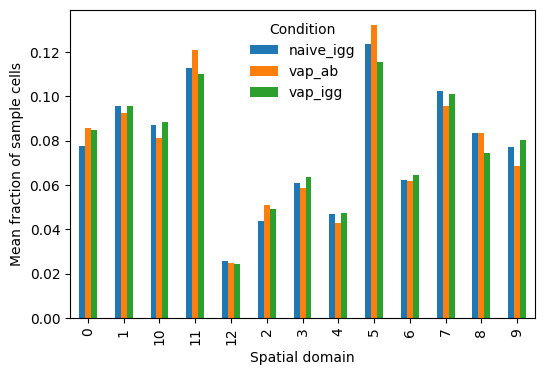

In [6]:
manifest = tables["manifest"]
display(
    pd.Series(
        {
            "cells": manifest["data"]["n_obs"],
            "samples": manifest["data"]["n_samples"],
            "conditions": ", ".join(manifest["data"]["conditions"]),
            "domains": len(manifest["data"]["compartments"]),
            "cell types": len(manifest["data"]["cell_types"]),
        }, name="run").to_frame())

domain_overview = summarize_compartments(tables["compartment_abundance"])
display(domain_overview)
plot_compartment_overview(domain_overview)

<Axes: title={'center': 'vap_46_igg: spatial domains'}, xlabel='x', ylabel='y'>

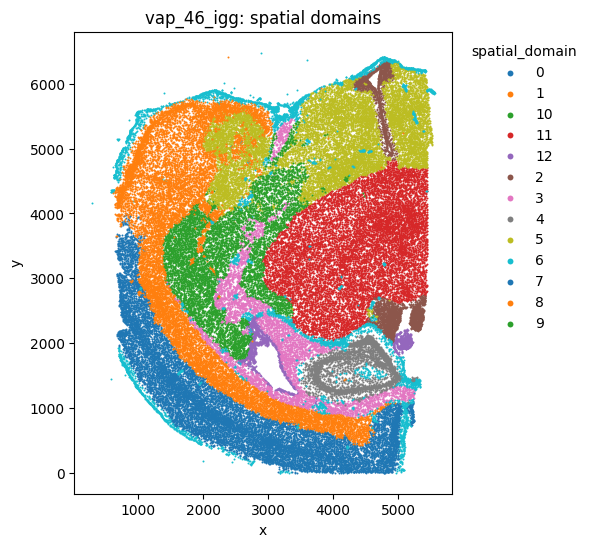

In [4]:
review_config = config.get("review", {})
sample_key = config["schema"]["sample_key"]
selected_sample = review_config.get("selected_sample")
if selected_sample is None:
    selected_sample = sorted(adata.obs[sample_key].astype(str).unique())[0]

plot_spatial_domains(
    adata,
    sample_col=sample_key,
    compartment_col=config["schema"]["spatial_domain_key"],
    spatial_key=config["schema"]["spatial_key"],
    sample=selected_sample,
)

## Cell-type composition by spatial domain

The composition summary compares the average cell-type mixture of each spatial domain. Choose `review.selected_domain` in the YAML file to focus the remaining panels; if it is unset, the notebook selects the first observed domain.

Selected domain for OLIG_sub7: 3
Selected domain: 3


,condition,cell_type,n_samples,mean_fraction,sd_fraction,mean_cells
0,naive_igg,OLIG_sub0,4,0.357628,0.042067,1596.00
1,naive_igg,OLIG_sub9,4,0.079939,0.015778,361.75
2,naive_igg,OLIG_sub5,4,0.079651,0.021255,356.25
3,naive_igg,OLIG_sub8,4,0.058792,0.006470,260.50
4,naive_igg,EC,4,0.051554,0.002427,228.75
...,...,...,...,...,...,...
142,vap_igg,IN-ChAT,4,0.000000,0.000000,0.00
143,vap_igg,IN-PV,4,0.000000,0.000000,0.00
144,vap_igg,IN-SST-RTN,4,0.000000,0.000000,0.00
145,vap_igg,MSN-D1,4,0.000000,0.000000,0.00


Selected domain: 3


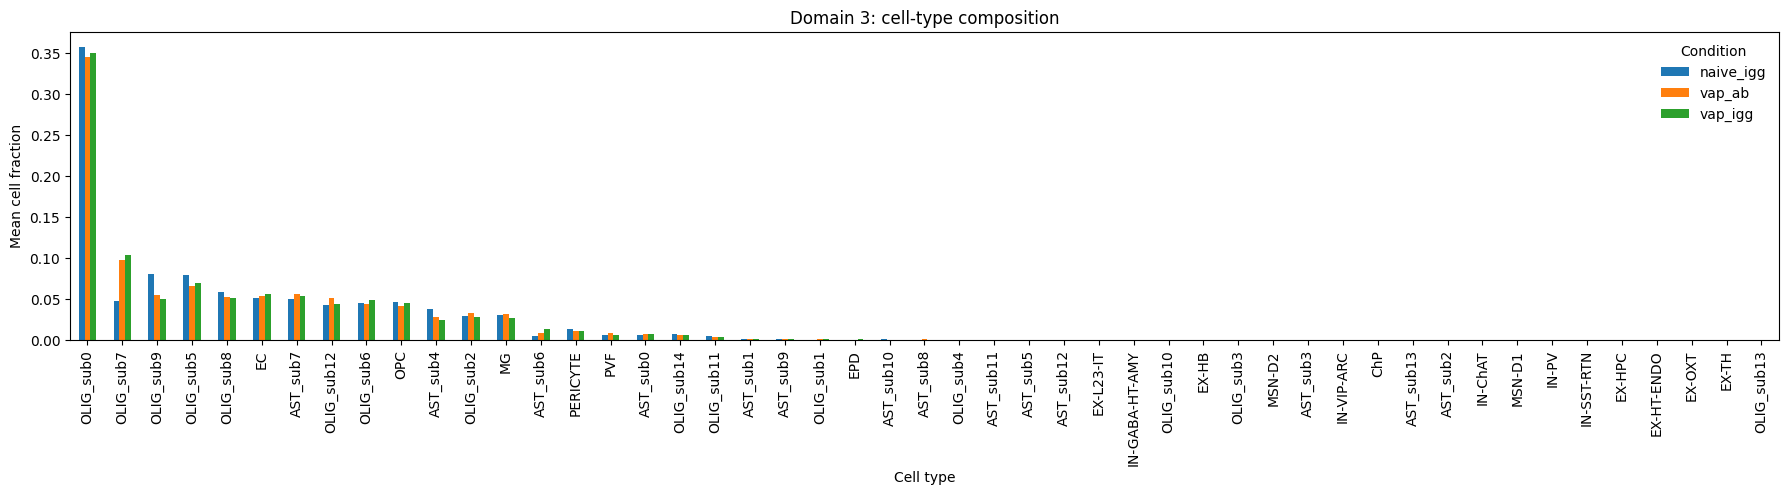

In [26]:
focal_cell_type = 'OLIG_sub7'

domains = available_compartments(tables["compartment_abundance"])
if focal_cell_type:
    selected_domain = tables['compartment_abundance'][tables['compartment_abundance']['cell_type'] == focal_cell_type].sort_values('cell_type_fraction', ascending=False)['compartment'].iloc[0]
else:
    selected_domain = review_config.get("selected_domain") or domains[0]


print(f"Selected domain for {focal_cell_type}: {selected_domain}")
print(f"Selected domain: {selected_domain}")

composition = compartment_composition(tables["compartment_abundance"], selected_domain)
display(composition)
plot_compartment_composition(composition, compartment=selected_domain)
print(f"Selected domain: {selected_domain}")

### Selected-domain counts by sample

Confirm that the selected domain and its major cell populations are represented in each biological sample.

In [24]:
df = tables['compartment_abundance'][tables['compartment_abundance']['compartment'] == selected_domain].copy()
df

,condition,sample,compartment,cell_type,n_cells,compartment_total_cells,sample_total_cells,cell_type_fraction,compartment_fraction
294,naive_igg,naive_70_igg,3,AST_sub0,23,4385,75390,0.005245,0.058164
295,naive_igg,naive_70_igg,3,AST_sub1,5,4385,75390,0.001140,0.058164
296,naive_igg,naive_70_igg,3,AST_sub10,3,4385,75390,0.000684,0.058164
297,naive_igg,naive_70_igg,3,AST_sub11,2,4385,75390,0.000456,0.058164
298,naive_igg,naive_70_igg,3,AST_sub12,0,4385,75390,0.000000,0.058164
...,...,...,...,...,...,...,...,...,...
7884,vap_igg,vap_51_igg,3,OLIG_sub8,299,4815,79958,0.062098,0.060219
7885,vap_igg,vap_51_igg,3,OLIG_sub9,293,4815,79958,0.060852,0.060219
7886,vap_igg,vap_51_igg,3,OPC,216,4815,79958,0.044860,0.060219
7887,vap_igg,vap_51_igg,3,PERICYTE,53,4815,79958,0.011007,0.060219


## Nearest-neighbor composition

The heatmap shows the mean fraction of neighboring cell types around a configurable source population, separated by condition. Set `review.selected_source_cell_type` in the YAML file to change the source.

In [6]:
nn_summary = tables["neighbor_composition_summary"]
# review.selected_source_cell_type
nn_summary

,condition,compartment,source_cell_type,neighbor_cell_type,n_samples,n_supporting_samples,total_source_cells,mean_neighbor_count,mean_neighbor_fraction,sd_neighbor_fraction,mean_neighbor_presence,sd_neighbor_presence
0,naive_igg,0,AST_sub0,AST_sub0,4,4,1115,69.00,0.043164,0.015371,0.211148,0.072710
1,naive_igg,0,AST_sub0,AST_sub1,4,4,1115,0.75,0.000488,0.000360,0.002684,0.001969
2,naive_igg,0,AST_sub0,AST_sub10,4,4,1115,1.25,0.000816,0.000216,0.004483,0.001215
3,naive_igg,0,AST_sub0,AST_sub11,4,4,1115,2.00,0.001466,0.001351,0.008038,0.007379
4,naive_igg,0,AST_sub0,AST_sub12,4,4,1115,0.00,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
100837,vap_igg,all,PVF,OLIG_sub8,4,4,13871,54.00,0.002548,0.000997,0.014248,0.005447
100838,vap_igg,all,PVF,OLIG_sub9,4,4,13871,71.25,0.003492,0.001011,0.018562,0.004442
100839,vap_igg,all,PVF,OPC,4,4,13871,151.25,0.007240,0.001770,0.037900,0.007256
100840,vap_igg,all,PVF,PERICYTE,4,4,13871,457.25,0.021997,0.003910,0.116212,0.018120


,condition,source_cell_type,n_samples,n_supporting_samples,total_source_cells
0,naive_igg,OLIG_sub7,4,4,825
1,vap_ab,OLIG_sub7,4,4,1625
2,vap_igg,OLIG_sub7,4,4,1884


neighbor_cell_type,AST_sub0,AST_sub1,AST_sub10,AST_sub11,AST_sub12,AST_sub4,AST_sub6,AST_sub7,AST_sub8,AST_sub9,...,OLIG_sub14,OLIG_sub2,OLIG_sub5,OLIG_sub6,OLIG_sub7,OLIG_sub8,OLIG_sub9,OPC,PERICYTE,PVF
condition,,,,,,,,,,,,,,,,,,,,,
naive_igg,0.002029,0.000146,0.000073,0.000000,0.000000,0.024760,0.019558,0.021466,0.000000,0.000000,...,0.003712,0.020141,0.045109,0.019455,0.241758,0.058496,0.120596,0.044099,0.007917,0.007833
vap_ab,0.002083,0.000161,0.000000,0.000000,0.000972,0.023053,0.037271,0.023187,0.000166,0.000244,...,0.003533,0.018345,0.039284,0.021786,0.416236,0.055888,0.037720,0.040087,0.008367,0.014023
vap_igg,0.004056,0.000035,0.000324,0.000035,0.000000,0.022218,0.034758,0.031964,0.000248,0.000106,...,0.003094,0.016835,0.040339,0.019089,0.422517,0.039691,0.038506,0.044973,0.007493,0.008348


<Axes: title={'center': 'Domain 3: neighbors of OLIG_sub7'}, xlabel='Neighbor cell type', ylabel='Condition'>

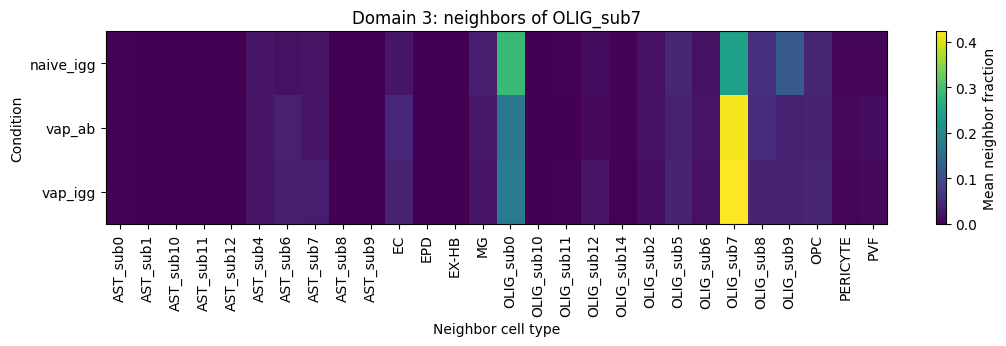

In [30]:
nn_summary = tables["neighbor_composition_summary"]
source_candidates = sorted(nn_summary.loc[nn_summary["compartment"].astype(str).eq(str(selected_domain)),"source_cell_type"].astype(str).unique())
selected_source = (review_config.get("selected_source_cell_type") or source_candidates[0])
support_table = (
    nn_summary.loc[
        nn_summary["compartment"].astype(str).eq(str(selected_domain))
        & nn_summary["source_cell_type"].astype(str).eq(str(selected_source)),
        [
            "condition",
            "source_cell_type",
            "n_samples",
            "n_supporting_samples",
            "total_source_cells",
        ],
    ]
    .drop_duplicates(["condition", "source_cell_type"]).sort_values(["condition", "source_cell_type"]).reset_index(drop=True))
display(support_table)
fraction_matrix = neighbor_fraction_matrix(nn_summary, compartment=selected_domain, source_cell_type=selected_source)
# remove columns with all zeros
fraction_matrix = fraction_matrix.loc[:, ~(fraction_matrix == 0).all()]
display(fraction_matrix)
plot_neighbor_fraction_heatmap(fraction_matrix, title=f"Domain {selected_domain}: neighbors of {selected_source}")

## Additional nearest-neighbor summaries

These read-only plots summarize neighbor proportions, enrichment, and condition differences using the shared `spatial-nncomp` plotting functions. Directional permutation testing is handled in Notebook 04.

In [8]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import spatial_nncomp as snn

neighbor_long = tables["neighbor_composition"].copy()
condition_order = [str(value) for value in manifest["data"]["conditions"]]
sample_dict = (
    neighbor_long[["condition", "sample"]]
    .drop_duplicates()
    .sort_values(["condition", "sample"], kind="stable")
    .groupby("condition", observed=True)["sample"]
    .apply(list)
    .reindex(condition_order)
    .to_dict()
)
celltype_order = sorted(
    set(neighbor_long["source_cell_type"].astype(str))
    | set(neighbor_long["neighbor_cell_type"].astype(str))
)


def _neighbor_matrix_tables(long_table, celltypes):
    sample_keys = ["condition", "sample", "compartment"]
    value_columns = {
        "nn_counts": "neighbor_count",
        "nn_frac": "neighbor_fraction",
        "nn_presence": "neighbor_presence",
    }
    sample_rows = []
    for keys, group in long_table.groupby(sample_keys, observed=True, sort=False):
        row = dict(zip(sample_keys, map(str, keys)))
        for output_name, value_name in value_columns.items():
            row[output_name] = (
                group.pivot(
                    index="source_cell_type",
                    columns="neighbor_cell_type",
                    values=value_name,
                )
                .reindex(index=celltypes, columns=celltypes)
                .fillna(0.0)
            )
        sample_rows.append(row)
    sample_table = pd.DataFrame(sample_rows)

    summary_rows = []
    for (condition, compartment), group in sample_table.groupby(
        ["condition", "compartment"], observed=True, sort=False
    ):
        row = {
            "condition": str(condition),
            "compartment": str(compartment),
            "n_samples": int(group["sample"].nunique()),
        }
        for value_name in ("nn_frac", "nn_presence"):
            values = np.stack(
                [matrix.to_numpy(dtype=float) for matrix in group[value_name]], axis=0
            )
            std = (
                values.std(axis=0, ddof=1)
                if len(values) > 1
                else np.zeros_like(values[0])
            )
            row[f"{value_name}_mean"] = pd.DataFrame(
                values.mean(axis=0), index=celltypes, columns=celltypes
            )
            row[f"{value_name}_std"] = pd.DataFrame(
                std, index=celltypes, columns=celltypes
            )
        summary_rows.append(row)
    return sample_table, pd.DataFrame(summary_rows)


nn_df, nn_summary_df = _neighbor_matrix_tables(neighbor_long, celltype_order)

schema = config["schema"]
rename_columns = {
    schema["condition_key"]: "condition",
    schema["sample_key"]: "sample",
    schema["spatial_domain_key"]: "compartment",
    schema["cell_type_key"]: "celltype",
}
plot_obs = adata.obs[list(rename_columns)].copy().rename(columns=rename_columns)
X, celltype_order, compartment_order, sample_meta, ix = snn.make_compartment_array(
    SimpleNamespace(obs=plot_obs),
    condition_order=condition_order,
    sample_order=sample_dict,
    condition_col="condition",
    sample_col="sample",
    comp_col="compartment",
    celltype_col="celltype",
)

abundance_columns = [
    "condition", "sample", "compartment", "cell_type", "n_cells"
]
comp_counts_df = (
    tables["compartment_abundance"][abundance_columns]
    .rename(columns={"cell_type": "celltype", "n_cells": "counts"})
    .copy()
)
source_celltype = str(selected_source)
nn_comp = str(selected_domain)
comparison_conditions = [
    condition for condition in ("naive_igg", "vap_igg") if condition in sample_dict
]
if len(comparison_conditions) != 2:
    comparison_conditions = condition_order[:2]
ref_condition = "vap_igg" if "vap_igg" in comparison_conditions else comparison_conditions[-1]

print(f"Focal cell type: {source_celltype}")
print(f"Focal compartment: {nn_comp}")
print(f"Conditions: {comparison_conditions}")

Focal cell type: OLIG_sub7
Focal compartment: 3
Conditions: ['naive_igg', 'vap_igg']


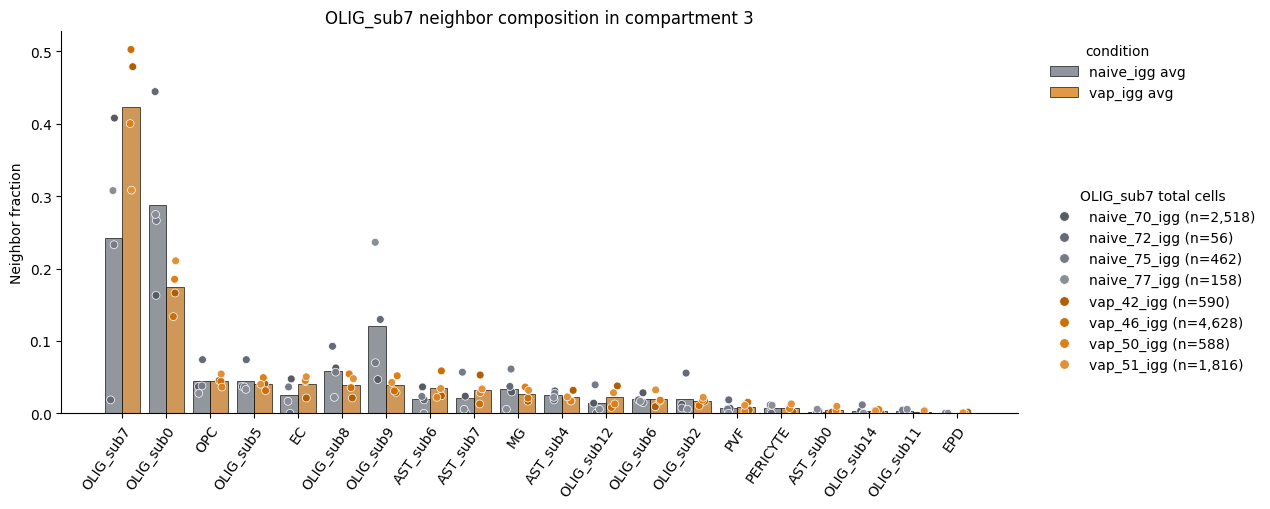

In [9]:
fig, ax, neighbor_plot_df = snn.plot_nn_prop(
    nn_df,
    celltype=source_celltype,
    ref_condition=ref_condition,
    conditions=comparison_conditions,
    sample_dict=sample_dict,
    comp=nn_comp,
    top_n=20,
    nn_summary_df=nn_summary_df,
    comp_col="compartment",
    condition_col="condition",
    sample_col="sample",
    comp_counts_df=comp_counts_df,
)
plt.show()

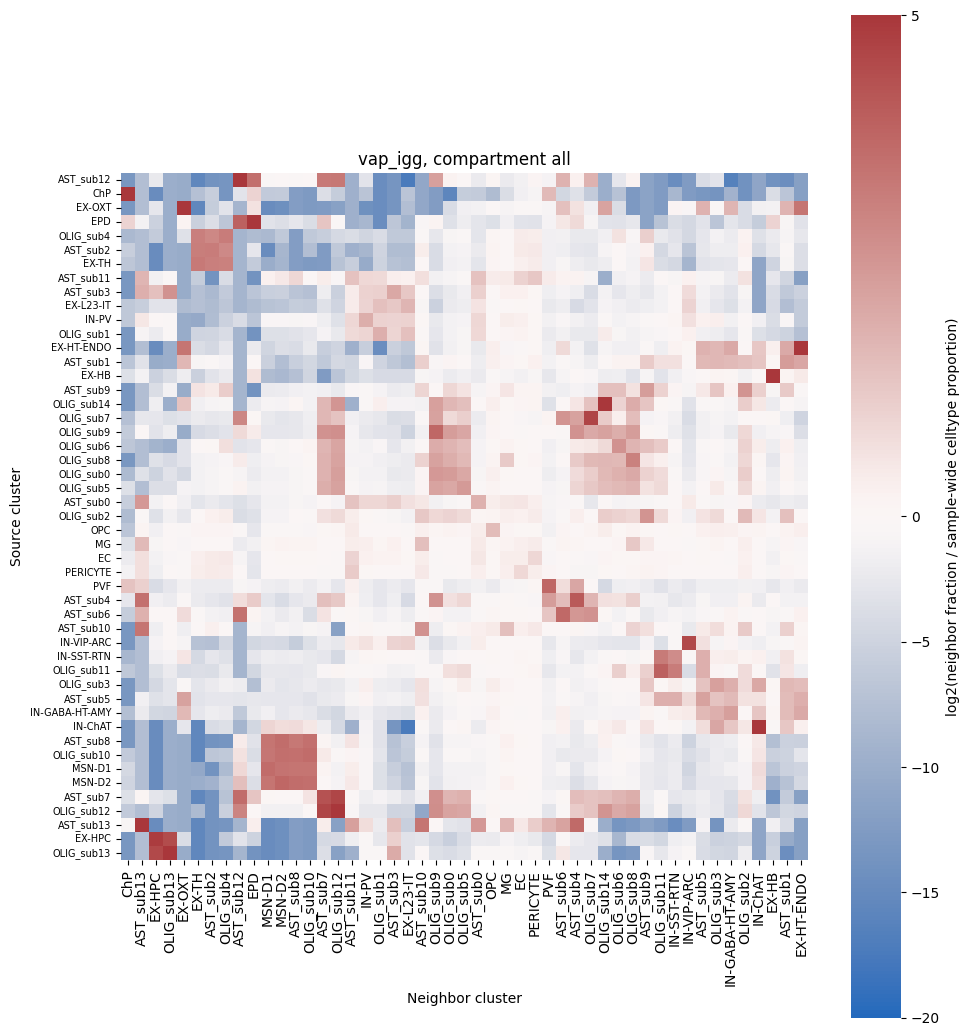

In [10]:
fig, axes, logfc_mats = snn.plot_nn_logfc_heatmap(
    nn_summary_df,
    data=X,
    conditions=["vap_igg"] if "vap_igg" in condition_order else [condition_order[0]],
    comp="all",
    comp_col="compartment",
    condition_col="condition",
    sample_col="sample",
    cluster_ref_condition=(
        "vap_igg" if "vap_igg" in condition_order else condition_order[0]
    ),
    condition_order=condition_order,
    sample_meta=sample_meta,
    celltype_order=celltype_order,
)
plt.show()

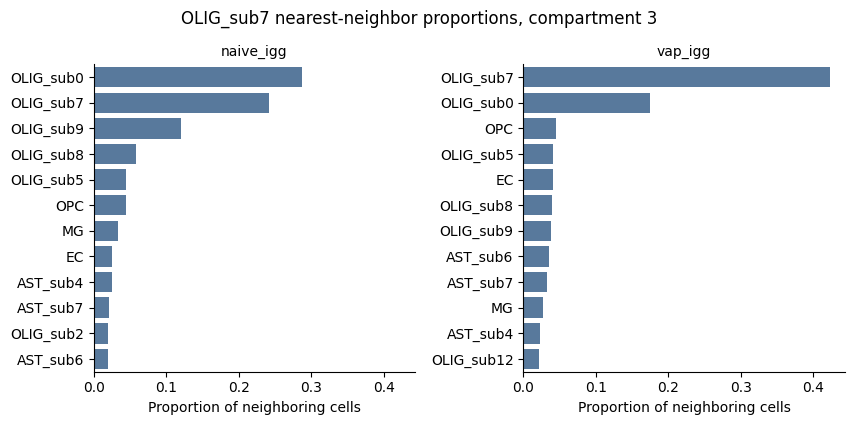

In [11]:
grid = snn.plot_nn_prop(
    nn_df,
    celltype=source_celltype,
    ref_condition=ref_condition,
    conditions=comparison_conditions,
    sample_dict=sample_dict,
    comp=nn_comp,
    top_n=12,
    nn_summary_df=nn_summary_df,
    comp_col="compartment",
    condition_col="condition",
    sample_col="sample",
    by_condition=True,
)
grid.fig.suptitle(
    f"{source_celltype} nearest-neighbor proportions, compartment {nn_comp}",
    y=1.05,
)
plt.show()

/path/to/liana/spatial-nncomp/src/spatial_nncomp/plots.py:1808: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


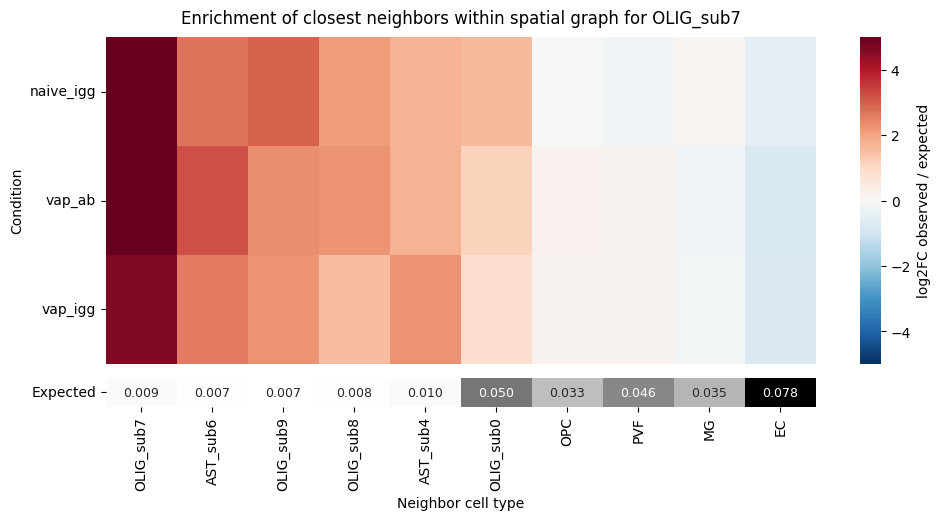

,condition,neighbor_celltype,log2fc_observed_expected
0,naive_igg,OLIG_sub7,5.219884
1,naive_igg,AST_sub6,2.699692
2,naive_igg,OLIG_sub9,2.935487
3,naive_igg,OLIG_sub8,2.111802
4,naive_igg,AST_sub4,1.743777
5,naive_igg,OLIG_sub0,1.627481
6,naive_igg,OPC,-0.037504
7,naive_igg,PVF,-0.187595
8,naive_igg,MG,0.116673
9,naive_igg,EC,-0.479017


In [12]:
fig, axes, enrichment_long = snn.plot_nn_for_celltype(
    nn_summary_df,
    source_cluster=source_celltype,
    conditions=condition_order,
    comp="all",
    data=X,
    top_n=10,
    comp_col="compartment",
    condition_col="condition",
    sample_col="sample",
    condition_order=condition_order,
    sample_meta=sample_meta,
    celltype_order=celltype_order,
)
plt.show()
display(enrichment_long.head(20))